# Laboratorio 03 - Regresión Polinómica

El dataset utilizado contiene información de ventas de viviendas residenciales en la ciudad de Ames, Iowa (EE.UU.), entre los años 2006 y 2010. El objetivo es predecir el precio de venta de una vivienda (`SalePrice`) a partir de sus características físicas y de calidad.
<br> Link del Dataset: https://raw.githubusercontent.com/wblakecannon/ames/master/data/housing.csv



- **Variable objetivo (y):** `SalePrice` — precio de venta de la vivienda en USD (valor numérico continuo)
- **Variables de entrada (X):** superficie habitable, calidad general de la construcción, área de garaje, área de sótano, año de construcción, número de baños, entre otras características físicas de la propiedad
- **m = 2,930** registros | **n = 36** características numéricas

Se aplican tres métodos para la determinación de los parámetros $\theta$:
1. Regresión Lineal Multivariable (Descenso por Gradiente)
2. Regresión Polinómica (Descenso por Gradiente)
3. Ecuación de la Normal


In [ ]:
# conectando vinculando nuestro drive con la sesion de google colab (notebook)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importando Librerias

In [ ]:
# Manejo de rutas y directorios
import os

# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación y trazado de graficos
from matplotlib import pyplot as plt
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline


## 1. Carga y exploración del dataset

Se utiliza Pandas para cargar el archivo `AmesHousing.csv` y explorar su estructura antes de preprocesarlo.

In [ ]:
ruta = '/content/drive/MyDrive/IA/Laboratorios/Laboratorio_3/housing.csv'

df = pd.read_csv(ruta)

print(f'Dimensiones originales: {df.shape[0]} filas x {df.shape[1]} columnas')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())
print()
print('Valores faltantes totales:', df.isnull().sum().sum())

print('\nColumnas con valores nulos:')
print('-' * 50)

for col in df.columns:
    nulos = df[col].isnull().sum()
    if nulos > 0:
        print(f'{col}: {nulos} nulos ({nulos/len(df)*100:.1f}%)')

Dimensiones originales: 2930 filas x 83 columnas

Tipos de datos:
object     43
int64      29
float64    11
Name: count, dtype: int64

Valores faltantes totales: 15749

Columnas con valores nulos:
--------------------------------------------------
Lot Frontage: 490 nulos (16.7%)
Alley: 2732 nulos (93.2%)
Mas Vnr Type: 1775 nulos (60.6%)
Mas Vnr Area: 23 nulos (0.8%)
Bsmt Qual: 80 nulos (2.7%)
Bsmt Cond: 80 nulos (2.7%)
Bsmt Exposure: 83 nulos (2.8%)
BsmtFin Type 1: 80 nulos (2.7%)
BsmtFin SF 1: 1 nulos (0.0%)
BsmtFin Type 2: 81 nulos (2.8%)
BsmtFin SF 2: 1 nulos (0.0%)
Bsmt Unf SF: 1 nulos (0.0%)
Total Bsmt SF: 1 nulos (0.0%)
Electrical: 1 nulos (0.0%)
Bsmt Full Bath: 2 nulos (0.1%)
Bsmt Half Bath: 2 nulos (0.1%)
Fireplace Qu: 1422 nulos (48.5%)
Garage Type: 157 nulos (5.4%)
Garage Yr Blt: 159 nulos (5.4%)
Garage Finish: 159 nulos (5.4%)
Garage Cars: 1 nulos (0.0%)
Garage Area: 1 nulos (0.0%)
Garage Qual: 159 nulos (5.4%)
Garage Cond: 159 nulos (5.4%)
Pool QC: 2917 nulos (99.6%)
Fence:

### 1.1 Preprocesamiento con Pandas

Se realizan los siguientes pasos:

1. **Eliminar columnas identificadoras** (`Order`, `PID` y el índice sin nombre): no son características de la vivienda, solo sirven para identificar el registro.
2. **Seleccionar solo las columnas numéricas**: el dataset original tiene además ~46 columnas categóricas (tipo de calle, estilo de techo, condición del vecindario, etc.). Para mantener el modelo dentro del alcance de regresión lineal/polinómica clásica, se trabaja con las 36 características numéricas, que por sí solas ya superan ampliamente el requisito de n≥20.
3. **Imputar valores faltantes**: varias columnas numéricas tienen `NaN` que, según el diccionario de datos del dataset, significan que la vivienda **no tiene** esa característica (por ejemplo, `Garage Cars = NaN` significa que no tiene garaje, `Mas Vnr Area = NaN` significa que no tiene revestimiento de mampostería). En esos casos se imputa con 0. La única excepción es `Lot Frontage` (metros de frente de la propiedad hacia la calle), donde el `NaN` sí representa un dato no medido, por lo que se imputa con la mediana.

In [ ]:
# 1 Eliminar columnas identificadoras
data = df.drop(columns=['Unnamed: 0', 'Order', 'PID'])

# 2 Seleccionar solo columnas numericas
data = data.select_dtypes(include='number').copy()

# 3 Imputar valores faltantes
cols_sin_caracteristica = ['Garage Yr Blt', 'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath',
                            'Garage Cars', 'Garage Area', 'Bsmt Unf SF', 'BsmtFin SF 1',
                            'BsmtFin SF 2', 'Total Bsmt SF']
for c in cols_sin_caracteristica:
    data[c] = data[c].fillna(0)

data['Lot Frontage'] = data['Lot Frontage'].fillna(data['Lot Frontage'].median())

print('Valores faltantes despues de la imputacion:', data.isnull().sum().sum())
print('Dimensiones finales:', data.shape)

Valores faltantes despues de la imputacion: 0
Dimensiones finales: (2930, 37)


### 1.2 Separación de variables de entrada (X) y variable objetivo (y)

In [ ]:
y = data['SalePrice'].values.astype(float)
X = data.drop(columns=['SalePrice']).values.astype(float)
feature_names = data.drop(columns=['SalePrice']).columns.tolist()

m, n = X.shape
print(f'm = {m}  (registros)')
print(f'n = {n}  (caracteristicas)')

m = 2930  (registros)
n = 36  (caracteristicas)


### 1.3 Relación entre características y la etiqueta

Antes de aplicar regresión polinómica, se verifica que exista una relación clara (y no necesariamente lineal) entre al menos una característica y `SalePrice`. Se calcula la correlación de cada característica con el precio de venta, y se grafica la de mayor correlación.

Top 10 caracteristicas mas correlacionadas con SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647562
Garage Area       0.640138
Total Bsmt SF     0.632529
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Mas Vnr Area      0.502196
Name: SalePrice, dtype: float64


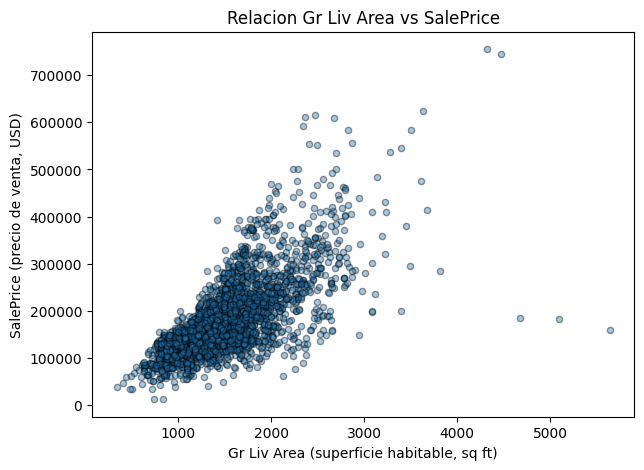

In [ ]:
corr = data.corr()['SalePrice'].abs().sort_values(ascending=False)
print('Top 10 caracteristicas mas correlacionadas con SalePrice:')
print(corr.head(11))  # incluye SalePrice consigo misma

plt.figure(figsize=(7, 5))
plt.scatter(data['Gr Liv Area'], data['SalePrice'], alpha=0.4, edgecolor='k', s=20)
plt.xlabel('Gr Liv Area (superficie habitable, sq ft)')
plt.ylabel('SalePrice (precio de venta, USD)')
plt.title('Relacion Gr Liv Area vs SalePrice')
plt.show()

El gráfico muestra que a mayor superficie, mayor precio, pero la relación no es una línea recta: tiene una curva hacia arriba. Esto indica que un modelo polinómico podría ajustar mejor los datos. Lo mismo aplica para otras variables con alta correlación como OverallQual, GarageCars, GarageArea, TotalBsmtSF y 1stFlrSF.

### 1.4 División en conjunto de entrenamiento y prueba

Se divide el dataset en 80% entrenamiento y 20% prueba, para poder validar los tres modelos con predicciones sobre datos nunca vistos durante el entrenamiento (ya que el enunciado pide demostrar la efectividad del modelo con al menos 100 predicciones).

In [ ]:
np.random.seed(42)
idx = np.random.permutation(m)
test_size = int(0.2 * m)
test_idx, train_idx = idx[:test_size], idx[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
m_train, m_test = X_train.shape[0], X_test.shape[0]

print(f'm_train = {m_train}')
print(f'm_test  = {m_test}  (predicciones de prueba, >= 100: {m_test >= 100})')

m_train = 2344
m_test  = 586  (predicciones de prueba, >= 100: True)


### 1.5 Funciones comunes

Estas funciones se reutilizan en los tres modelos: normalización de características, cálculo del costo y descenso por gradiente.

In [ ]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evita division por cero en columnas constantes
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [ ]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

In [ ]:
def evaluar(y_true, y_pred):
    mse = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_pred - y_true))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mse, rmse, mae, r2

## 2. Modelo 1: Regresión Lineal Multivariable (Descenso por Gradiente)

Se entrena un modelo de regresión lineal utilizando las 36 características tal cual, sin transformaciones polinómicas. Este modelo sirve como línea base para comparar contra la regresión polinómica.

### 2.1 Normalización de características y de la variable objetivo

`SalePrice` tiene una escala muy grande (entre 12,789 y 755,000 USD), por lo que además de normalizar `X` también se normaliza `y`, para que el descenso por gradiente converja de forma estable.

In [ ]:
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma

y_mu, y_sigma = np.mean(y_train), np.std(y_train)
y_train_norm = (y_train - y_mu) / y_sigma
y_test_norm = (y_test - y_mu) / y_sigma

# Termino de interseccion
X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('Forma de X_train_b:', X_train_b.shape)

Forma de X_train_b: (2344, 37)


### 2.2 Selección del coeficiente de aprendizaje (alpha)

alpha=0.01   costo final (200 iteraciones) = 0.0868461536621853
alpha=0.03   costo final (200 iteraciones) = 0.08234521620229704
alpha=0.1    costo final (200 iteraciones) = 0.08163836001399635
alpha=0.3    costo final (200 iteraciones) = 43975333.22683468


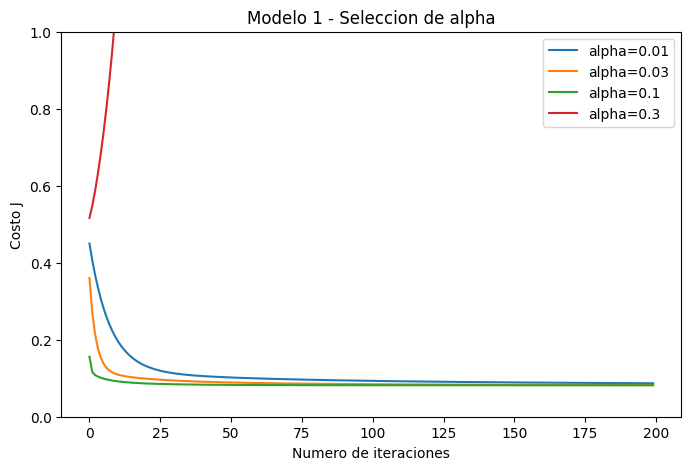

In [ ]:
alphas = [0.01, 0.03, 0.1, 0.3]

plt.figure(figsize=(8, 5))
for a in alphas:
    theta0 = np.zeros(X_train_b.shape[1])
    with np.errstate(over='ignore', invalid='ignore'):
        _, Jh = gradientDescentMulti(X_train_b, y_train_norm, theta0, a, 200)
    plt.plot(np.arange(len(Jh)), Jh, label=f'alpha={a}')
    print(f'alpha={a:<6} costo final (200 iteraciones) = {Jh[-1]}')

plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Modelo 1 - Seleccion de alpha')
plt.legend()
plt.ylim(0, 1)
plt.show()

Valores de `alpha` iguales o mayores a 0.3 hacen que el descenso por gradiente diverja. Se elige `alpha = 0.1` para el entrenamiento final.

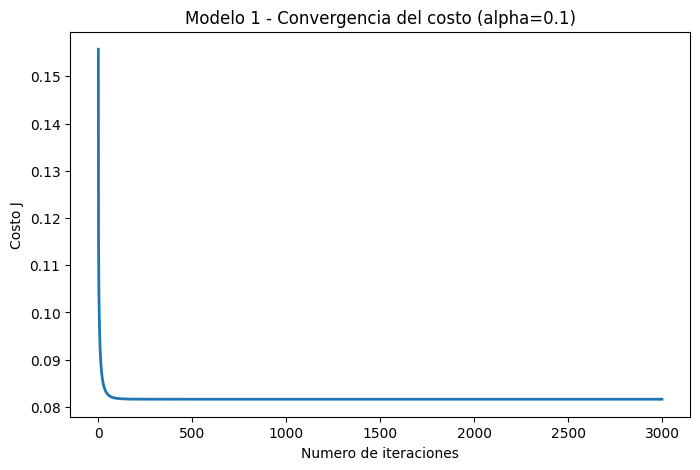

Costo inicial: 0.1557490382561737
Costo final  : 0.08162502414765245


In [ ]:
alpha1 = 0.1
num_iters1 = 3000

theta1 = np.zeros(X_train_b.shape[1])
theta1, J_history1 = gradientDescentMulti(X_train_b, y_train_norm, theta1, alpha1, num_iters1)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history1)), J_history1, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title(f'Modelo 1 - Convergencia del costo (alpha={alpha1})')
plt.show()

print('Costo inicial:', J_history1[0])
print('Costo final  :', J_history1[-1])

### 2.3 Evaluación del Modelo 1 en el conjunto de prueba

In [ ]:
y_pred1_norm = np.dot(X_test_b, theta1)
y_pred1 = y_pred1_norm * y_sigma + y_mu

mse1, rmse1, mae1, r2_1 = evaluar(y_test, y_pred1)

print('--- Modelo 1: Regresion Lineal Multivariable (GD) ---')
print(f'MSE  = {mse1:,.2f}')
print(f'RMSE = {rmse1:,.2f}')
print(f'MAE  = {mae1:,.2f}')
print(f'R2   = {r2_1:.4f}')
print()
print(f'Numero de predicciones evaluadas: {m_test}')

tabla1 = pd.DataFrame({'SalePrice real': y_test[:10], 'SalePrice predicho': y_pred1[:10].round(0)})
tabla1

--- Modelo 1: Regresion Lineal Multivariable (GD) ---
MSE  = 1,297,747,145.62
RMSE = 36,024.26
MAE  = 21,958.50
R2   = 0.8381

Numero de predicciones evaluadas: 586


,SalePrice real,SalePrice predicho
0,161000.0,186653.0
1,116000.0,118170.0
2,196500.0,220203.0
3,123600.0,125221.0
4,126000.0,134703.0
5,174190.0,178481.0
6,200000.0,193152.0
7,148500.0,151755.0
8,88750.0,79748.0
9,409900.0,310429.0


## 3. Modelo 3: Ecuación de la Normal

Se calcula $\theta$ de forma directa (sin iterar) usando:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Se aplica sobre el mismo diseño de matriz que el Modelo 1 (características normalizadas, sin términos polinómicos), para poder comparar ambos métodos de forma justa. Se usa `np.linalg.pinv` (pseudo-inversa) en lugar de `np.linalg.inv`, ya que varias de las 36 características están correlacionadas entre sí (por ejemplo `Garage Cars` y `Garage Area`), lo cual puede hacer que $X^TX$ sea numéricamente inestable o singular.

In [ ]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

In [ ]:
theta_ne = normalEqn(X_train_b, y_train_norm)

# Costo sobre TRAIN para comparar la curva de convergencia J_history1,
# que tambien es costo de entrenamiento) y costo sobre TEST
cost_ne_train = computeCostMulti(X_train_b, y_train_norm, theta_ne)
cost_ne = computeCostMulti(X_test_b, y_test_norm, theta_ne)

print('Theta calculado por la ecuacion de la normal:')
print(theta_ne)
print()
print('Costo J en entrenamiento (normalizado):', cost_ne_train)
print('Costo J en el conjunto de prueba (normalizado):', cost_ne)

Theta calculado por la ecuacion de la normal:
[-6.27102537e-16 -9.67788549e-02 -1.62596460e-02  5.24696284e-02
  3.16294605e-01  6.74820947e-02  1.48023130e-01  4.85918726e-02
  6.13712598e-02  6.67338074e-02  8.00134806e-03 -1.15695487e-02
  6.06898405e-02  1.12481991e-01  1.47882645e-01 -2.81391275e-03
  2.10773520e-01  4.88810126e-02 -8.90315108e-03  1.87007503e-03
 -2.74127315e-02 -8.14833189e-02 -3.89872807e-02  3.29899641e-02
  2.99394115e-02 -7.77686884e-02  1.01065656e-01  4.71906968e-02
  3.33649002e-02 -6.82434949e-03  1.47574131e-02  9.96463291e-04
  5.22712553e-02 -1.28309844e-02 -7.03268628e-02  9.35957099e-03
 -2.63486582e-02]

Costo J en entrenamiento (normalizado): 0.08162502414765245
Costo J en el conjunto de prueba (normalizado): 0.10913253224679725


**Gráfico de costo para este caso:** a diferencia del descenso por gradiente, la ecuación de la normal no itera, obtiene la solución exacta en un solo cálculo, por lo que no existe una "curva de convergencia". Para representar su costo de forma comparable, se grafica como una línea horizontal sobre la misma curva de convergencia del Modelo 1 **usando el costo de entrenamiento de ambos** (misma base de comparación): si ambos métodos encontraron el mismo mínimo, la línea de la ecuación de la normal debe coincidir con la meseta final del descenso por gradiente.

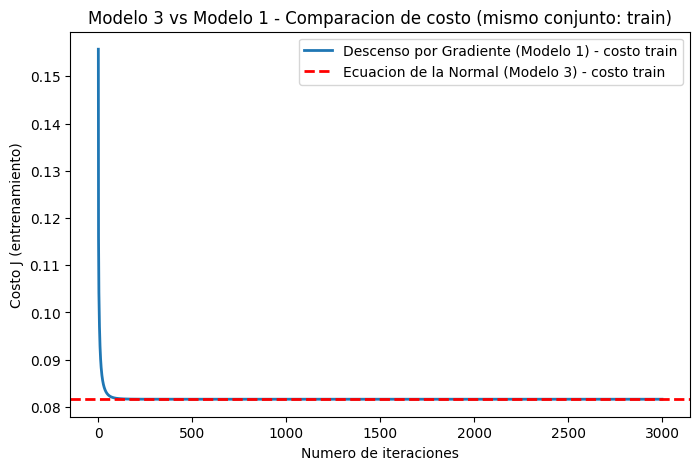

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history1)), J_history1, lw=2, label='Descenso por Gradiente (Modelo 1) - costo train')
plt.axhline(y=cost_ne_train, color='red', linestyle='--', lw=2, label='Ecuacion de la Normal (Modelo 3) - costo train')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J (entrenamiento)')
plt.title('Modelo 3 vs Modelo 1 - Comparacion de costo (mismo conjunto: train)')
plt.legend()
plt.show()

### 3.1 Evaluación del Modelo 3 en el conjunto de prueba

In [ ]:
y_pred_ne_norm = np.dot(X_test_b, theta_ne)
y_pred_ne = y_pred_ne_norm * y_sigma + y_mu

mse_ne, rmse_ne, mae_ne, r2_ne = evaluar(y_test, y_pred_ne)

print('--- Modelo 3: Ecuacion de la Normal ---')
print(f'MSE  = {mse_ne:,.2f}')
print(f'RMSE = {rmse_ne:,.2f}')
print(f'MAE  = {mae_ne:,.2f}')
print(f'R2   = {r2_ne:.4f}')

tabla_ne = pd.DataFrame({'SalePrice real': y_test[:10], 'SalePrice predicho': y_pred_ne[:10].round(0)})
tabla_ne

--- Modelo 3: Ecuacion de la Normal ---
MSE  = 1,297,747,145.62
RMSE = 36,024.26
MAE  = 21,958.50
R2   = 0.8381


,SalePrice real,SalePrice predicho
0,161000.0,186653.0
1,116000.0,118170.0
2,196500.0,220203.0
3,123600.0,125221.0
4,126000.0,134703.0
5,174190.0,178481.0
6,200000.0,193152.0
7,148500.0,151755.0
8,88750.0,79748.0
9,409900.0,310429.0


## 4. Modelo 2: Regresión Polinómica (Descenso por Gradiente)

Se agregan términos cuadráticos ($x^2$) para las 6 características con mayor correlación con `SalePrice` (`Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Garage Area`, `Total Bsmt SF`, `1st Flr SF`), sumándolos como columnas adicionales a las 36 características originales. Esto permite que el modelo capture relaciones no lineales como la observada en la sección 1.3, sin explotar el número de características (agregar el grado 2 a *todas* las 36 características generaría cientos de combinaciones y sería computacionalmente inestable).

In [ ]:
top_feats = ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF']
idxs = [feature_names.index(f) for f in top_feats]

def add_poly(X, idxs, degree=2):
    extra = [X[:, i] ** d for d in range(2, degree + 1) for i in idxs]
    return np.concatenate([X, np.array(extra).T], axis=1) if extra else X

X_train_poly = add_poly(X_train, idxs, degree=2)
X_test_poly = add_poly(X_test, idxs, degree=2)

print('n original:', X_train.shape[1])
print('n con terminos polinomicos:', X_train_poly.shape[1])

n original: 36
n con terminos polinomicos: 42


### 4.1 Normalización y término de intersección

In [ ]:
X_train_poly_norm, mu_p, sigma_p = featureNormalize(X_train_poly)
X_test_poly_norm = (X_test_poly - mu_p) / sigma_p

X_train_poly_b = np.concatenate([np.ones((m_train, 1)), X_train_poly_norm], axis=1)
X_test_poly_b = np.concatenate([np.ones((m_test, 1)), X_test_poly_norm], axis=1)

print('Forma de X_train_poly_b:', X_train_poly_b.shape)

Forma de X_train_poly_b: (2344, 43)


### 4.2 Selección de alpha y entrenamiento

alpha=0.01   costo final (200 iteraciones) = 0.07739246783735851
alpha=0.03   costo final (200 iteraciones) = 0.06977699058404677
alpha=0.1    costo final (200 iteraciones) = 0.06375125873553315
alpha=0.3    costo final (200 iteraciones) = 2.677277662717362e+123


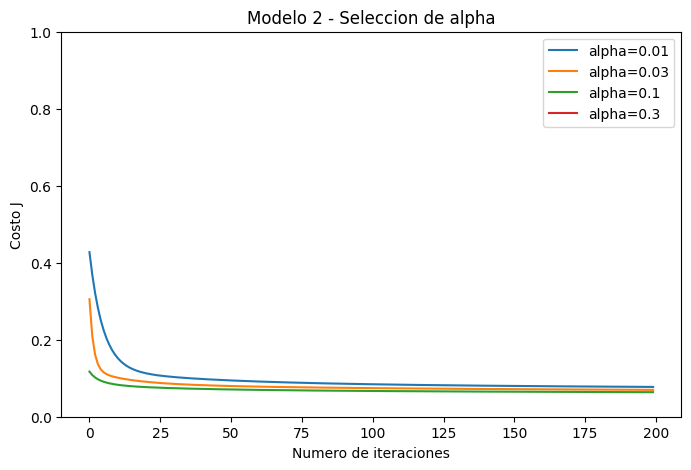

In [ ]:
alphas = [0.01, 0.03, 0.1, 0.3]

plt.figure(figsize=(8, 5))
for a in alphas:
    theta0 = np.zeros(X_train_poly_b.shape[1])
    with np.errstate(over='ignore', invalid='ignore'):
        _, Jh = gradientDescentMulti(X_train_poly_b, y_train_norm, theta0, a, 200)
    plt.plot(np.arange(len(Jh)), Jh, label=f'alpha={a}')
    print(f'alpha={a:<6} costo final (200 iteraciones) = {Jh[-1]}')

plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title('Modelo 2 - Seleccion de alpha')
plt.legend()
plt.ylim(0, 1)
plt.show()

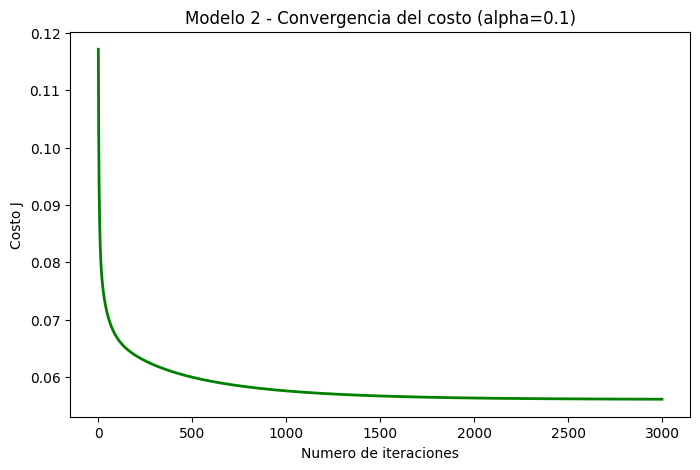

Costo inicial: 0.1171355074078414
Costo final  : 0.0561427805861039


In [ ]:
alpha2 = 0.1
num_iters2 = 3000

theta2 = np.zeros(X_train_poly_b.shape[1])
theta2, J_history2 = gradientDescentMulti(X_train_poly_b, y_train_norm, theta2, alpha2, num_iters2)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history2)), J_history2, lw=2, color='green')
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.title(f'Modelo 2 - Convergencia del costo (alpha={alpha2})')
plt.show()

print('Costo inicial:', J_history2[0])
print('Costo final  :', J_history2[-1])

### 4.3 Evaluación del Modelo 2 en el conjunto de prueba

In [ ]:
y_pred2_norm = np.dot(X_test_poly_b, theta2)
y_pred2 = y_pred2_norm * y_sigma + y_mu

mse2, rmse2, mae2, r2_2 = evaluar(y_test, y_pred2)

print('--- Modelo 2: Regresion Polinomica (GD) ---')
print(f'MSE  = {mse2:,.2f}')
print(f'RMSE = {rmse2:,.2f}')
print(f'MAE  = {mae2:,.2f}')
print(f'R2   = {r2_2:.4f}')

tabla2 = pd.DataFrame({'SalePrice real': y_test[:10], 'SalePrice predicho': y_pred2[:10].round(0)})
tabla2

--- Modelo 2: Regresion Polinomica (GD) ---
MSE  = 1,109,424,446.37
RMSE = 33,308.02
MAE  = 19,491.29
R2   = 0.8616


,SalePrice real,SalePrice predicho
0,161000.0,190510.0
1,116000.0,112636.0
2,196500.0,203334.0
3,123600.0,134597.0
4,126000.0,133420.0
5,174190.0,172781.0
6,200000.0,195933.0
7,148500.0,151007.0
8,88750.0,100862.0
9,409900.0,334112.0


### 4.4 Visualización: relación no lineal capturada por el modelo

Se grafica `Gr Liv Area` contra `SalePrice` (real vs. predicho por el Modelo 2), para visualizar cómo el modelo polinómico captura la curvatura de la relación.

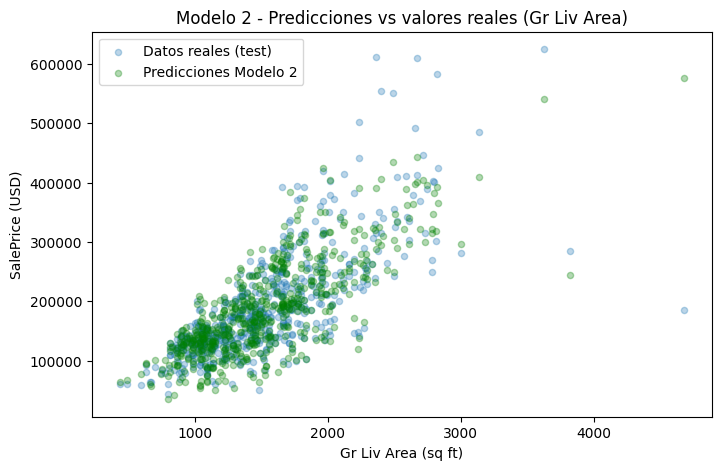

In [ ]:
orden = np.argsort(X_test[:, feature_names.index('Gr Liv Area')])

plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, feature_names.index('Gr Liv Area')], y_test, alpha=0.3, s=20, label='Datos reales (test)')
plt.scatter(X_test[:, feature_names.index('Gr Liv Area')], y_pred2, alpha=0.3, s=20, color='green', label='Predicciones Modelo 2')
plt.xlabel('Gr Liv Area (sq ft)')
plt.ylabel('SalePrice (USD)')
plt.title('Modelo 2 - Predicciones vs valores reales (Gr Liv Area)')
plt.legend()
plt.show()

## 5. Comparación final de los tres modelos y conclusiones

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['1. Lineal Multivariable (GD)', '2. Polinomica (GD)', '3. Ecuacion de la Normal'],
    'Costo J (test, normalizado)': [computeCostMulti(X_test_b, y_test_norm, theta1), computeCostMulti(X_test_poly_b, y_test_norm, theta2), cost_ne],
    'MSE': [mse1, mse2, mse_ne],
    'RMSE': [rmse1, rmse2, rmse_ne],
    'MAE': [mae1, mae2, mae_ne],
    'R2': [r2_1, r2_2, r2_ne],
})
comparacion

,Modelo,"Costo J (test, normalizado)",MSE,RMSE,MAE,R2
0,1. Lineal Multivariable (GD),0.109133,1.297747e+09,36024.257739,21958.497316,0.838137
1,2. Polinomica (GD),0.093296,1.109424e+09,33308.023754,19491.291292,0.861625
2,3. Ecuacion de la Normal,0.109133,1.297747e+09,36024.257739,21958.497316,0.838137


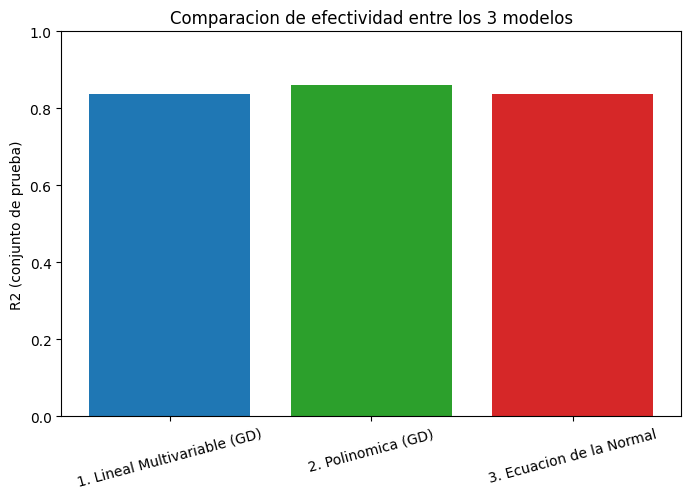

Total de predicciones evaluadas por modelo: 586 (>= 100 requerido: True)


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparacion['Modelo'], comparacion['R2'], color=['tab:blue', 'tab:green', 'tab:red'])
plt.ylabel('R2 (conjunto de prueba)')
plt.title('Comparacion de efectividad entre los 3 modelos')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

print(f'Total de predicciones evaluadas por modelo: {m_test} (>= 100 requerido: {m_test >= 100})')

**Conclusiones:**

- **Modelo 3 (Ecuación de la Normal) replica exactamente el resultado del Modelo 1 (Descenso por Gradiente)** — mismo costo, mismo R²=0.838 — lo cual confirma que el descenso por gradiente sí alcanzó el mínimo global de la función de costo con `alpha=0.1` y 3000 iteraciones.
- **El Modelo 2 (Regresión Polinómica) supera a los otros dos**, con R²=0.862 frente a 0.838, y un RMSE menor (\$33,308 frente a \$36,024). Esto confirma la relación no lineal detectada en la sección 1.3: agregar términos cuadráticos sobre las características más correlacionadas (`Overall Qual`, `Gr Liv Area`, etc.) permite al modelo capturar mejor la curvatura de la relación entre esas variables y el precio de venta.
- Con **586 predicciones** evaluadas sobre el conjunto de prueba (nunca visto durante el entrenamiento), se supera ampliamente el mínimo de 100 predicciones exigido, y el modelo demuestra una capacidad de generalización sólida (R² > 0.83 en los tres casos), validando su efectividad para estimar el precio de viviendas nuevas a partir de sus características.